In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Mall_customers.csv')
df.head() 

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
x = df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]
x.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [4]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [5]:
from sklearn.cluster import KMeans
wcss = [] 

for i in range(1,11): 
    kmeans = KMeans(n_clusters=i , random_state=42 , n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\susha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\susha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\susha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\susha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

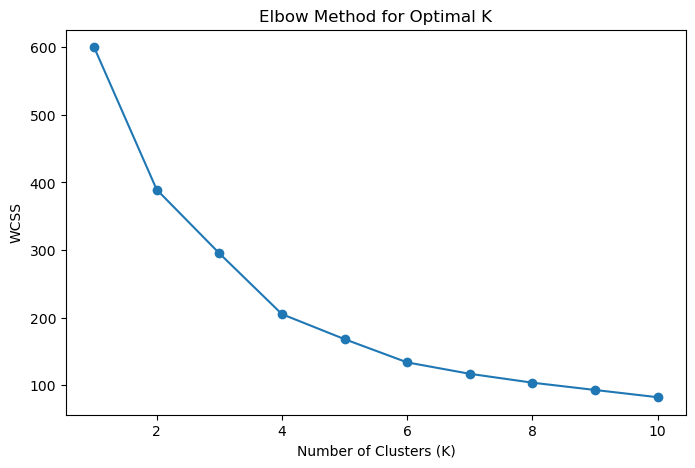

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [26]:
kmeans = KMeans(n_clusters=5,random_state=42 , n_init=10)
kmeans.fit(x_scaled) 

C:\Users\susha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [27]:
clusters = kmeans.fit_predict(x_scaled)
df['Clusters'] = clusters
df.head() 

C:\Users\susha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


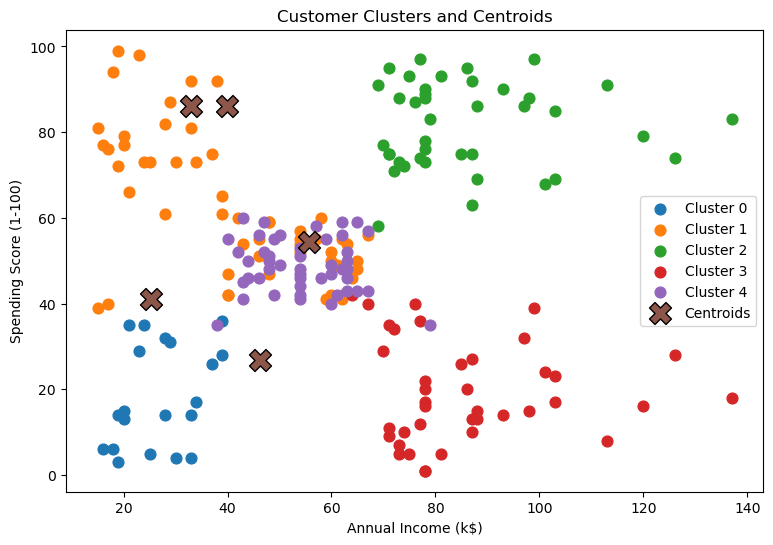

In [28]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
for cluster in sorted(df['Clusters'].unique()):
    cluster_data = df[df['Clusters'] == cluster]
    plt.scatter(
    cluster_data['Annual Income (k$)'],
    cluster_data['Spending Score (1-100)'],
    label=f'Cluster {cluster}',
    s=60
    )
plt.scatter(
centroids_original[:, 0],
centroids_original[:, 1],
marker='X',
s=250,
edgecolors='black',
label='Centroids'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters and Centroids")
plt.legend()
plt.show()

In [29]:
cluster_summary = df.groupby('Clusters')[[ 'Age','Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [30]:
from sklearn.metrics import silhouette_score
silhouette = silhouette_score(x_scaled, clusters)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.41664341513732767


In [31]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Clusters'],
      dtype='object')

<Axes: xlabel='Clusters', ylabel='Age'>

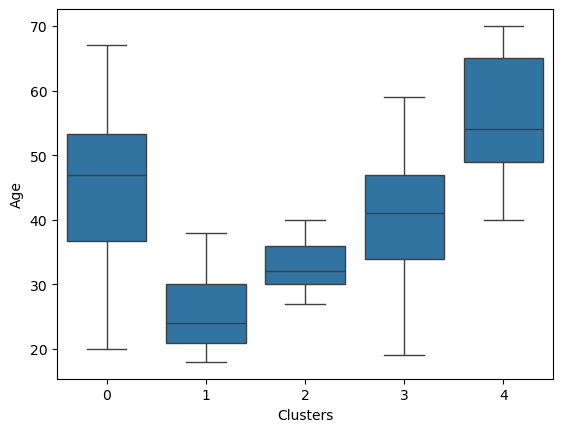

In [34]:
import seaborn as sns 
sns.boxplot(x=df[ 'Clusters'], y=df['Age'])